In [7]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    ConfusionMatrixDisplay
)


In [8]:
df = pd.read_csv('K:/Data Science Internship/WEEK 5/datasets/Telco-Customer-Churn-dataset-cleaned.csv')
df.head()


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,tenure-binned,MonthlyCharges-binned,TotalCharges-binned,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,...,No,Month-to-month,Yes,Electronic check,29.85,29.85,Low,Low,Low,0.0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,No,One year,No,Mailed check,56.95,1889.50,Medium,Medium,Low,0.0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,No,Month-to-month,Yes,Mailed check,53.85,108.15,Low,Medium,Low,1.0
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,...,No,One year,No,Bank transfer (automatic),42.30,1840.75,Medium,Low,Low,0.0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,...,No,Month-to-month,Yes,Electronic check,70.70,151.65,Low,Medium,Low,1.0


In [9]:
X = df.drop("Churn", axis=1)
y = df["Churn"]
X = pd.get_dummies(X, drop_first=True)

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [11]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [12]:
model = SVC(
    kernel='rbf',      # radial basis function (nonlinear)
    probability=True,  # needed for ROC-AUC
    random_state=42
)

model.fit(X_train_scaled, y_train)


SVC(probability=True, random_state=42)

In [13]:
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]


In [14]:
acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred)
auc  = roc_auc_score(y_test, y_prob)

print("Accuracy :", acc)
print("Precision:", prec)
print("Recall   :", rec)
print("F1 Score :", f1)
print("ROC-AUC  :", auc)


Accuracy : 0.8126330731014905
Precision: 0.6872852233676976
Recall   : 0.5361930294906166
F1 Score : 0.6024096385542169
ROC-AUC  : 0.8200531534981937


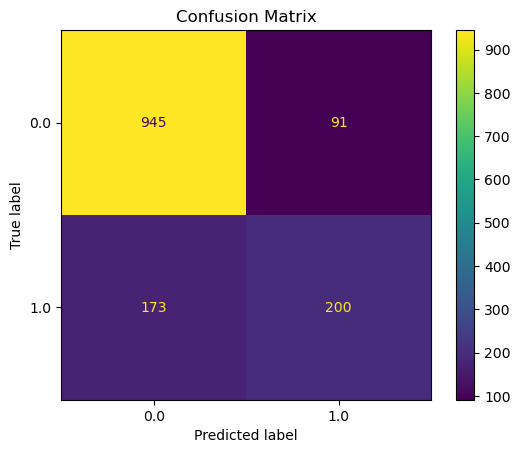

In [15]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("Confusion Matrix")
plt.show()


# 🧾Report :

“The SVM classifier achieved an accuracy of 81.26%, indicating good overall classification performance. The ROC-AUC score of 0.82 suggests strong separability between classes. However, recall (53.62%) is lower than precision (68.73%), implying that the model misses a portion of actual positive instances.”